# RetainIQ — Phase 5.2: Clustering & Segment Model Selection

## Objective

I will evaluate K-Means cluster counts from 2 through 8 using:

- inertia
- elbow analysis
- silhouette score
- segment-size balance
- stability across random seeds

I will select a working cluster count from these observed diagnostics.

## 1. Connect to MySQL

In [1]:
from getpass import getpass
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq",
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        return pd.DataFrame(cursor.fetchall())
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

print("MySQL segmentation connection is ready.")

MySQL segmentation connection is ready.


## 2. Build the Clustering Matrix

In [2]:
query = """
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_revenue,
    f.cltv,
    f.satisfaction_score,
    d.age,
    d.number_of_dependents,
    a.number_of_referrals,
    a.total_extra_data_charges,
    a.total_long_distance_charges,
    a.referred_a_friend,
    a.paperless_billing,
    a.contract,
    a.payment_method,
    a.offer,
    s.internet_type,
    s.avg_monthly_gb_download,
    s.avg_monthly_long_distance_charges,
    s.phone_service,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.premium_tech_support,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data
FROM fact_customer_status f
JOIN dim_demographics d ON f.customer_id = d.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id;
"""

df = run_query(query)

numeric_features = [
    "tenure_months","monthly_charge","total_revenue","cltv",
    "satisfaction_score","age","number_of_dependents",
    "number_of_referrals","total_extra_data_charges",
    "total_long_distance_charges","avg_monthly_gb_download",
    "avg_monthly_long_distance_charges"
]

for column in numeric_features:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(df[column].median())

service_columns = [
    "phone_service","online_security","online_backup",
    "device_protection_plan","premium_tech_support",
    "streaming_tv","streaming_movies","streaming_music",
    "unlimited_data"
]

for column in service_columns:
    df[f"{column}_flag"] = (
        df[column].fillna("").astype(str).str.strip().str.lower().eq("yes").astype(int)
    )

df["service_count"] = df[
    [f"{column}_flag" for column in service_columns]
].sum(axis=1)

df["referred_friend_flag"] = (
    df["referred_a_friend"].fillna("").astype(str).str.strip().str.lower().eq("yes").astype(int)
)

df["paperless_billing_flag"] = (
    df["paperless_billing"].fillna("").astype(str).str.strip().str.lower().eq("yes").astype(int)
)

numeric_features += [
    "service_count",
    "referred_friend_flag",
    "paperless_billing_flag"
]

categorical_features = [
    "contract",
    "internet_type",
    "payment_method",
    "offer"
]

features = df[
    ["customer_id"] + numeric_features + categorical_features
].copy()

for column in categorical_features:
    features[column] = features[column].fillna("Unknown").astype(str)

feature_matrix = pd.get_dummies(
    features.drop(columns=["customer_id"]),
    columns=categorical_features,
    dtype=float
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

print(f"Clustering matrix: {X_scaled.shape}")

Clustering matrix: (7043, 31)


## 3. Evaluate Candidate Cluster Counts

In [3]:
candidate_k = range(2, 9)
cluster_scores = []

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)
    shares = pd.Series(labels).value_counts(normalize=True)

    cluster_scores.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "smallest_cluster_share_pct": shares.min() * 100,
        "largest_cluster_share_pct": shares.max() * 100
    })

cluster_scores = pd.DataFrame(cluster_scores)
cluster_scores

,k,inertia,silhouette_score,smallest_cluster_share_pct,largest_cluster_share_pct
0,2,"192,517.843",0.124,40.310,59.690
1,3,"174,027.969",0.132,22.107,45.804
2,4,"164,890.481",0.116,21.681,27.219
3,5,"158,251.423",0.119,7.355,25.685
4,6,"151,999.152",0.131,7.326,25.387
5,7,"145,968.201",0.125,5.892,20.446
6,8,"140,547.782",0.130,5.892,18.245


## 4. Elbow Analysis

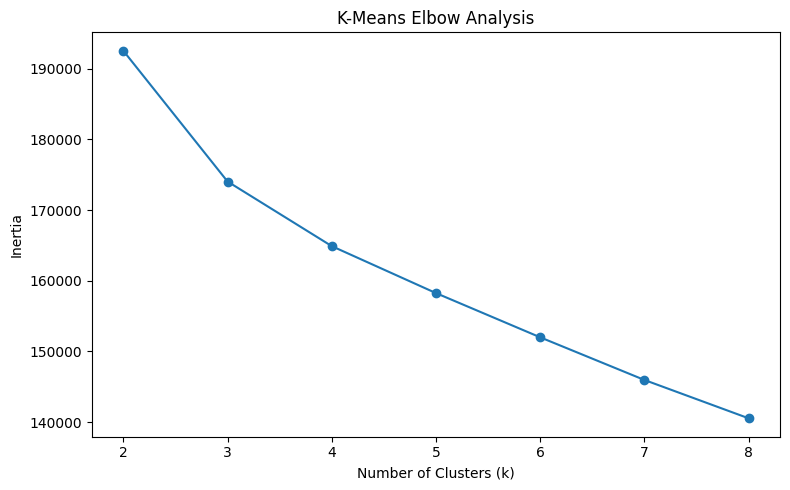

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    cluster_scores["k"],
    cluster_scores["inertia"],
    marker="o"
)
ax.set_title("K-Means Elbow Analysis")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

## 5. Silhouette Analysis

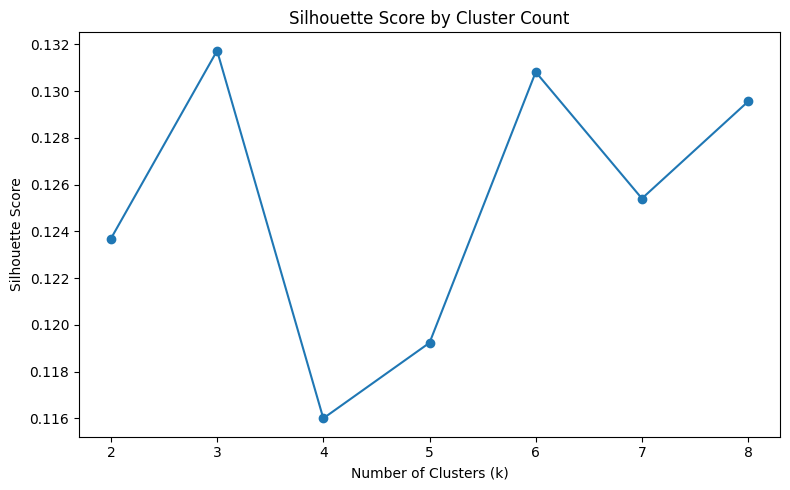

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    cluster_scores["k"],
    cluster_scores["silhouette_score"],
    marker="o"
)
ax.set_title("Silhouette Score by Cluster Count")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

## 6. Select the Working Cluster Count

In [6]:
recommended_k = int(
    cluster_scores.loc[
        cluster_scores["silhouette_score"].idxmax(),
        "k"
    ]
)

selected_k = recommended_k

print(f"Recommended k from silhouette analysis: {recommended_k}")
print(f"Working cluster count: {selected_k}")

Recommended k from silhouette analysis: 3
Working cluster count: 3


## 7. Fit K-Means

In [7]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=50
)

labels = kmeans.fit_predict(X_scaled)

assignments = pd.DataFrame({
    "customer_id": features["customer_id"],
    "segment_id": labels
})

assignments.head()

,customer_id,segment_id
0,0002-ORFBO,0
1,0003-MKNFE,0
2,0004-TLHLJ,0
3,0011-IGKFF,0
4,0013-EXCHZ,0


## 8. Check Segment Balance

In [8]:
segment_sizes = (
    assignments["segment_id"]
    .value_counts()
    .sort_index()
    .rename("customers")
    .reset_index()
)

segment_sizes["share_pct"] = (
    segment_sizes["customers"]
    / len(assignments)
    * 100
).round(2)

segment_sizes

,segment_id,customers,share_pct
0,0,3226,45.800
1,1,1557,22.110
2,2,2260,32.090


## 9. Stability Across Random Seeds

In [9]:
seeds = [42, 52, 62, 72, 82]
seed_labels = []

for seed in seeds:
    model = KMeans(
        n_clusters=selected_k,
        random_state=seed,
        n_init=20
    )

    seed_labels.append(
        model.fit_predict(X_scaled)
    )

stability_rows = []

for i in range(1, len(seed_labels)):
    stability_rows.append({
        "comparison": f"{seeds[0]} vs {seeds[i]}",
        "adjusted_rand_index": adjusted_rand_score(
            seed_labels[0],
            seed_labels[i]
        )
    })

stability_df = pd.DataFrame(stability_rows)
stability_df

,comparison,adjusted_rand_index
0,42 vs 52,0.999
1,42 vs 62,0.999
2,42 vs 72,0.999
3,42 vs 82,0.999


## 10. PCA Projection

Variance explained by first two components: 28.75%


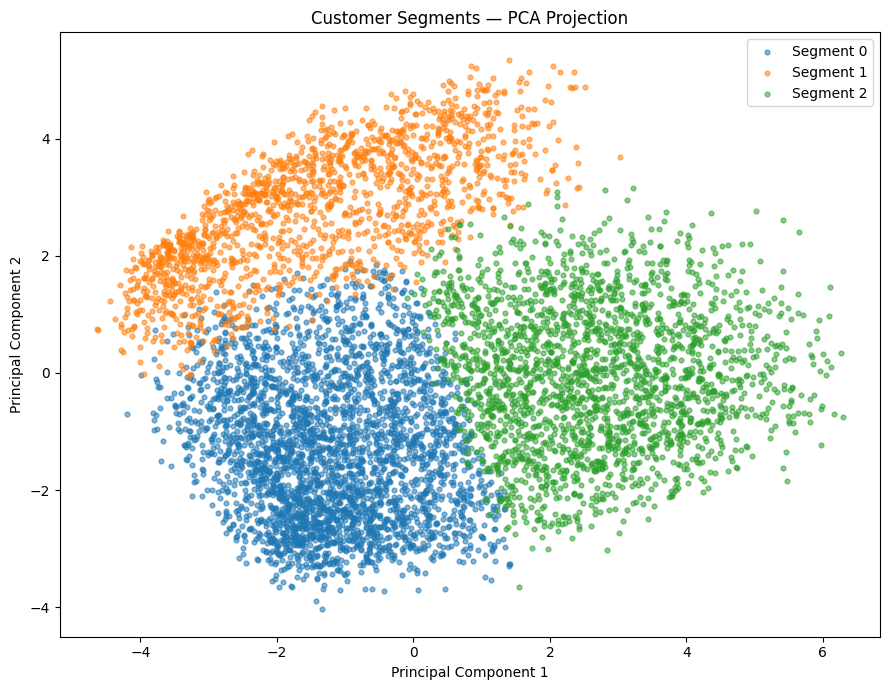

In [10]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "customer_id": features["customer_id"],
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "segment_id": labels
})

print(
    f"Variance explained by first two components: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

fig, ax = plt.subplots(figsize=(9, 7))

for segment_id in sorted(pca_df["segment_id"].unique()):
    subset = pca_df[
        pca_df["segment_id"] == segment_id
    ]

    ax.scatter(
        subset["pc1"],
        subset["pc2"],
        s=12,
        alpha=0.55,
        label=f"Segment {segment_id}"
    )

ax.set_title("Customer Segments — PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()

plt.tight_layout()
plt.show()

## 11. Export Clustering Artifacts

In [11]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

cluster_scores.to_csv(
    output_dir / "cluster_selection_metrics.csv",
    index=False
)

stability_df.to_csv(
    output_dir / "cluster_stability_metrics.csv",
    index=False
)

assignments.to_csv(
    output_dir / "customer_segment_assignments.csv",
    index=False
)

pca_df.to_csv(
    output_dir / "segment_pca_coordinates.csv",
    index=False
)

print("Clustering artifacts exported.")

Clustering artifacts exported.


# Phase 5.2 Conclusion

I evaluated candidate cluster structures, selected a working K-Means solution, checked cluster
stability, and exported the segment assignments.

**Next:** profile the segments by value, behavior, services, churn, and revenue.